# מטלת סיום – חלק 2 | Movie Rating Prediction
**חברי הצוות:**
* שיראל חדד - [212546017]
* עינב יינון - [211415351]

**קישור למאגר הפרויקט ב-GitHub:**
https://github.com/shirelhaddad/machine-learning/tree/main

## ייבוא ספריות

In [2]:
import re
import ast
import bisect
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import joblib
from matplotlib.patches import Patch

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model    import ElasticNet
from sklearn.ensemble        import RandomForestRegressor
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from IPython.display         import display, HTML

In [3]:
def style_table(df, title=None, highlight_col=None, higher_is_better=True):
    styled = df.style\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px 14px'),
                       ('letter-spacing', '0.5px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#f5f6fa')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#eaf0fb')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        ])\
        .set_table_attributes(
            'style="border-collapse: collapse; font-family: sans-serif; font-size: 13px;"')

    if title:
        styled = styled.set_caption(title)\
            .set_table_styles([{'selector': 'caption',
                                'props': [('font-size', '14px'),
                                          ('font-weight', 'bold'),
                                          ('color', '#2c3e50'),
                                          ('padding-bottom', '8px')]}], overwrite=False)

    if highlight_col and highlight_col in df.columns:
        best_color  = '#d5e8d4'
        worst_color = '#f8cecc'
        if higher_is_better:
            styled = styled.highlight_max(subset=[highlight_col], color=best_color)
            styled = styled.highlight_min(subset=[highlight_col], color=worst_color)
        else:
            styled = styled.highlight_min(subset=[highlight_col], color=best_color)
            styled = styled.highlight_max(subset=[highlight_col], color=worst_color)

    return styled

## טעינת הדאטה

In [4]:
dataset = pd.read_csv("dataset.csv", na_values=['\\N', 'N/A', 'null'], low_memory=False)
# טעינת קובץ של הבמאים 
df_crew = pd.read_csv("title.crew.tsv.gz", sep='\t', usecols=['tconst', 'directors'], low_memory=False)
# מיזוג של הקבצים לדאטה שכוללת את הבמאים 
dataset = pd.merge(dataset, df_crew, on='tconst', how='left')

## בניית פונקציות עזר לניקוי הנתונים 

In [5]:
# פונקציות ניקוי 
def _clean_year(val):
    if pd.isna(val):
        return np.nan
    try:
        year = int(float(val))
        if re.fullmatch(r'\d{4}', str(year)):
            return year
        return np.nan
    except (ValueError, TypeError):
        return np.nan 
 
def _clean_runtime(val):
    # רק מספר ולא טקסט
    if pd.isna(val):
        return np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan
 
def _clean_rating(val):
    # ערך תקין בין 1.0-10.0
    if pd.isna(val):
        return np.nan
    try:
        r = float(val)
        return r if 1.0 <= r <= 10.0 else np.nan
    except (ValueError, TypeError):
        return np.nan
 
 
def _clean_genres(val):
    # מחזיר רשימת זאנרים נקייה
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|\[\])$', s, re.IGNORECASE):
        return []
    try:
        parsed = ast.literal_eval(s)
        items  = [str(g).strip() for g in parsed] \
                 if isinstance(parsed, list) else [str(parsed).strip()]
    except (ValueError, SyntaxError):
        items = re.split(r'[,|;]', s)
    cleaned = []
    for item in items:
        g = item.strip().title()
        if g and re.match(r'^[A-Za-z\- ]{2,30}$', g):
            if not re.match(r'^(N/A|\\N|Nan|None|Na)$', g, re.IGNORECASE):
                cleaned.append(g)
    return cleaned
  
def _clean_actors(val):
    # בודק שהשחקן באמת עומד בקריטריונים עם התחלה של nm
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|\[\]|N/A)$', s, re.IGNORECASE):
        return []
    return re.findall(r'nm\d{7,8}', s)
 
 
def _clean_director(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|nan|none)$', s, re.IGNORECASE):
        return np.nan
    matches = re.findall(r'nm\d{7,8}', s)
    if not matches:
        return np.nan
    return ','.join(matches)

## בניית פיצרים


In [6]:
def _safe_list(val):
    if isinstance(val, list): return val
    if pd.isna(val): return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [x.strip() for x in str(val).split(',') if x.strip()]

def add_static_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['num_genres']   = df['genres'].apply(lambda g: len(_safe_list(g)))
    df['is_too_short'] = (df['runtimeMinutes'] < 75).astype(float)
    df['is_too_long']  = (df['runtimeMinutes'] > 150).astype(float)
    return df

## חישוב היחס בין אורך הסרט לחציון הסרטים עפי גאנר - רק סרטים של שנה קטנה מהשנה הנוכחית
class RelativeRuntimeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['genres', 'startYear', 'runtimeMinutes']].copy()
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        df = df.dropna(subset=['startYear', 'runtimeMinutes']).sort_values('startYear')
        self.genre_history_ = {}
        for genre, group in df.groupby('_first_genre'):
            self.genre_history_[genre] = {
                'years':    group['startYear'].values,
                'runtimes': group['runtimeMinutes'].values}
        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')

        def calc(row):
            genre        = row['_first_genre']
            current_year = row['startYear']
            if genre not in self.genre_history_ or pd.isna(current_year):
                return np.nan
            years_array   = self.genre_history_[genre]['years']
            idx           = bisect.bisect_left(years_array, current_year)
            if idx == 0:
                return np.nan
            past_runtimes = self.genre_history_[genre]['runtimes'][:idx]
            median        = np.median(past_runtimes)
            if pd.isna(median) or median == 0:
                return np.nan
            return row['runtimeMinutes'] / median

        X['relative_runtime_by_genre'] = X.apply(calc, axis=1)
        return X.drop(columns=['_first_genre'])

## ניסיון השחקן הכי מנוסה בסרט (מקסימום, לא ממוצע — כדי לא לדלל את הכוכב)
class ActorExpTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['lead_actors_ids', 'startYear']].dropna().copy()
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(lambda x: _safe_list(x))
        df = df.explode('lead_actors_ids').sort_values('startYear')
        self.actor_years_ = df.groupby('lead_actors_ids')['startYear'].apply(list).to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        def calc(row):
            actors = _safe_list(row['lead_actors_ids'])
            year   = row['startYear']
            if not actors or pd.isna(year):
                return pd.Series({'max_actors_past_experience': 0.0, 'is_new_actors': 1.0})
            exp     = [bisect.bisect_left(self.actor_years_.get(a, []), year) for a in actors]
            max_exp = float(max(exp))
            return pd.Series({'max_actors_past_experience': max_exp,
                              'is_new_actors': 1.0 if max_exp == 0 else 0.0})

        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)
        return X

class DirectorAvgTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        orig_df = X[['genres', 'startYear']].copy()
        orig_df['averageRating'] = y
        orig_df['_first_genre']  = orig_df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        orig_df = orig_df.dropna(subset=['startYear', 'averageRating']).sort_values('startYear')

        self.global_years_   = orig_df['startYear'].values
        self.global_ratings_ = orig_df['averageRating'].values

        self.genre_history_ = {}
        for g, group in orig_df.groupby('_first_genre'):
            self.genre_history_[g] = {
                'years':   group['startYear'].values,
                'ratings': group['averageRating'].values}

        df = X[['directors', 'genres', 'startYear']].copy()
        df['averageRating'] = y
        df['_first_genre']  = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        df['directors'] = df['directors'].apply(lambda x: _safe_list(x))
        df = df.explode('directors').dropna(
            subset=['directors', 'startYear', 'averageRating']).sort_values('startYear')

        # תיקון: שומרים את ה-DataFrame הפנימי כקובץ נתונים מסודר לכל במאי
        self.dir_history_ = {}
        for d, group in df.groupby('directors'):
            self.dir_history_[d] = group[['startYear', 'averageRating', '_first_genre']].copy()

        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')

        def calc(row):
            year               = row['startYear']
            genre              = row['_first_genre']
            current_directors  = _safe_list(row['directors'])

            if pd.isna(year):
                return pd.Series({
                    'director_past_avg':      np.nan,
                    'is_new_director':        1.0,
                    'director_genre_past_avg': np.nan})

            idx_global      = bisect.bisect_left(self.global_years_, year)
            global_past_avg = np.mean(self.global_ratings_[:idx_global]) if idx_global > 0 else np.nan

            genre_past_avg = global_past_avg
            if genre in self.genre_history_:
                idx_genre = bisect.bisect_left(self.genre_history_[genre]['years'], year)
                if idx_genre > 0:
                    genre_past_avg = np.mean(self.genre_history_[genre]['ratings'][:idx_genre])

            dir_past_ratings       = []
            dir_genre_past_ratings = []

            for d in current_directors:
                if d in self.dir_history_:
                    # תיקון: סינון היסטוריית הבמאי בצורה מפורשת וחסינת זליגה
                    hist = self.dir_history_[d]
                    past_movies = hist[hist['startYear'] < year] # לוקח רק סרטים משנים קודמות באמת!
                    
                    if not past_movies.empty:
                        dir_past_ratings.extend(past_movies['averageRating'].tolist())
                        
                        # סינון ספציפי לפי ז'אנר
                        genre_movies = past_movies[past_movies['_first_genre'] == genre]
                        if not genre_movies.empty:
                            dir_genre_past_ratings.extend(genre_movies['averageRating'].tolist())

            if dir_past_ratings:
                res_dir_avg    = np.mean(dir_past_ratings)
                res_is_new_dir = 0.0
            else:
                res_dir_avg    = global_past_avg
                res_is_new_dir = 1.0

            if dir_genre_past_ratings:
                res_dir_genre_avg   = np.mean(dir_genre_past_ratings)
            else:
                res_dir_genre_avg   = genre_past_avg

            return pd.Series({
                'director_past_avg':       res_dir_avg,
                'is_new_director':         res_is_new_dir,
                'director_genre_past_avg': res_dir_genre_avg})

        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)
        return X.drop(columns=['_first_genre'])

## prepare_data

In [7]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # אם directors לא קיים — מנסים לטעון מקובץ הצוות
    if 'directors' not in df.columns:
        try:
            _crew = pd.read_csv("title.crew.tsv.gz", sep='\t',
                                usecols=['tconst', 'directors'], low_memory=False)
            df = pd.merge(df, _crew, on='tconst', how='left')
        # אם הקובץ לא קיים — עמודה ריקה
        except Exception:
            df['directors'] = np.nan
            
    # מימוש פונקציות העזר של הניקוי
    df['startYear']      = df['startYear'].apply(_clean_year)
    df['runtimeMinutes'] = df['runtimeMinutes'].apply(_clean_runtime)
    df['genres']          = df['genres'].apply(_clean_genres)
    df['lead_actors_ids'] = df['lead_actors_ids'].apply(_clean_actors)
    df['directors']       = df['directors'].apply(_clean_director)

    # הוספת הפיצ'רים הפשוטים
    df = add_static_features(df)

    # ניקוי שורות ריקות של משתנה המטרה רק בשלב האימון 
    if 'averageRating' in df.columns:
        df['averageRating'] = df['averageRating'].apply(_clean_rating)
        df = df.dropna(subset=['averageRating']).reset_index(drop=True)

    # הסרת עמודות לא רלוונטיות
    COLS_TO_DROP = ['numVotes', 'BoxOffice', 'plot', 'Language', 'Country', 'budget']
    df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

    return df

## הכנת דאטת האימון

In [8]:
dataset_clean = prepare_data(dataset.copy())

_raw = dataset.copy()
_raw['averageRating'] = _raw['averageRating'].apply(_clean_rating)
_raw['startYear']     = _raw['startYear'].apply(_clean_year)
_raw['genres']        = _raw['genres'].apply(_clean_genres)
_raw = _raw.dropna(subset=['averageRating', 'startYear']).sort_values('startYear').reset_index(drop=True)

y = dataset_clean['averageRating'].values
X = dataset_clean.drop(columns=['averageRating'])

## ומודלים Pipeline הגדרת

In [9]:
# רשימת הפיצ'רים המספריים הסופיים 
FEATURE_COLS = [
    'startYear', 'num_genres', 'is_too_short', 'is_too_long','is_new_director', 'is_new_actors',
    'relative_runtime_by_genre', 'director_past_avg', 'max_actors_past_experience', 'director_genre_past_avg']
 
feature_engineering_pipeline = Pipeline(steps=[
    ('relative_runtime', RelativeRuntimeTransformer()),
    ('actor_exp', ActorExpTransformer()),
    ('director_avg', DirectorAvgTransformer())])

# הגדרת ה-Preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())]), FEATURE_COLS)], remainder='drop')

# הגדרת רשתות פרמטרים 
param_grid_en = {'alpha':    [0.001, 0.01, 0.1],
                 'l1_ratio': [0.2, 0.5, 0.8],}
param_grid_rf = {'max_depth':        [6, 10, 15],
                'min_samples_leaf': [10, 20, 40],}
# ה-Pipelines הסופיים והמוגנים מ-Data Leakage
pipeline_en = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline),
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        ElasticNet(max_iter=2000, random_state=42),
        param_grid_en, cv=3, scoring='neg_mean_squared_error', n_jobs=-1 )),
])

pipeline_rf = Pipeline(steps=[
    ('feature_eng', clone(feature_engineering_pipeline)), 
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        RandomForestRegressor(n_estimators=60, random_state=42, n_jobs=-1),
        param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)),
])

## CV הרצת

In [10]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def run_stability_cv(pipeline, X, y, model_name):
    fold_metrics = []
    oof_preds = np.zeros(len(y))

    for fold_num, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]

        pipeline.fit(X_train, y_train)
        preds_test = pipeline.predict(X_test)
        oof_preds[test_idx] = preds_test

        fold_metrics.append({
            'fold': fold_num + 1,
            'r2':   r2_score(y_test, preds_test),
            'rmse': np.sqrt(mean_squared_error(y_test, preds_test)),
            'mae':  mean_absolute_error(y_test, preds_test),
        })

    metrics_df = pd.DataFrame(fold_metrics)
    r2   = metrics_df['r2'].mean();   r2_s  = metrics_df['r2'].std()
    rmse = metrics_df['rmse'].mean(); rmse_s = metrics_df['rmse'].std()
    mae  = metrics_df['mae'].mean();  mae_s  = metrics_df['mae'].std()

    display(HTML(f"""
        <div style="margin:16px 0; padding:14px 20px; border-left:5px solid #2c3e50;
                    background:#f5f6fa; font-family:sans-serif; border-radius:4px;">
            <div style="font-size:15px; font-weight:bold; color:#2c3e50; margin-bottom:8px;">
                {model_name}
            </div>
            <table style="border-collapse:collapse; font-size:13px;">
                <tr>
                    <td style="padding:3px 16px 3px 0; color:#555;">R²</td>
                    <td style="font-weight:bold; color:#2c3e50;">{r2:.4f}</td>
                    <td style="color:#888; padding-left:8px;">± {r2_s:.4f}</td>
                </tr>
                <tr>
                    <td style="padding:3px 16px 3px 0; color:#555;">RMSE</td>
                    <td style="font-weight:bold; color:#2c3e50;">{rmse:.4f}</td>
                    <td style="color:#888; padding-left:8px;">± {rmse_s:.4f}</td>
                </tr>
                <tr>
                    <td style="padding:3px 16px 3px 0; color:#555;">MAE</td>
                    <td style="font-weight:bold; color:#2c3e50;">{mae:.4f}</td>
                    <td style="color:#888; padding-left:8px;">± {mae_s:.4f}</td>
                </tr>
            </table>
        </div>
    """))

    return oof_preds, metrics_df

# הרצה בפועל
oof_en, stability_en = run_stability_cv(pipeline_en, X, y, 'Elastic Net')
oof_rf, stability_rf = run_stability_cv(pipeline_rf, X, y, 'Random Forest')

# טבלת השוואה סופית
comparison_df = pd.DataFrame({
    'Model':      ['Elastic Net', 'Random Forest'],
    'R² (mean)':  [stability_en['r2'].mean(),   stability_rf['r2'].mean()],
    'RMSE (mean)':[stability_en['rmse'].mean(),  stability_rf['rmse'].mean()],
    'MAE (mean)': [stability_en['mae'].mean(),   stability_rf['mae'].mean()],
    'RMSE (std)': [stability_en['rmse'].std(),   stability_rf['rmse'].std()],
}).round(4)

display(HTML("""
    <div style="margin:20px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            השוואת מודלים
        </span>
    </div>
"""))
display(style_table(comparison_df, highlight_col='RMSE (mean)', higher_is_better=False))

R²,0.2368,± 0.0056
RMSE,1.1293,± 0.0099
MAE,0.8637,± 0.0076


R²,0.2956,± 0.0073
RMSE,1.0849,± 0.0099
MAE,0.8240,± 0.0077


,Model,R² (mean),RMSE (mean),MAE (mean),RMSE (std)
0,Elastic Net,0.236800,1.129300,0.863700,0.009900
1,Random Forest,0.295600,1.084900,0.824000,0.009900


## ניתוח שגיאות

In [11]:
# בניית טבלת שגיאות 
errors_df = X[['tconst', 'primaryTitle', 'startYear', 'genres', 'directors']].copy()
errors_df['y_true']   = y
errors_df['pred_rf']  = oof_rf
errors_df['pred_en']  = oof_en
errors_df['error_rf'] = oof_rf - y 
errors_df['error_en'] = oof_en - y
errors_df['first_genre'] = errors_df['genres'].apply(
    lambda g: g[0] if isinstance(g, list) and g else 'Unknown')
# מעבירים את טבלת X דרך צינור הפיצ'רים שלנו באופן חד-פעמי רק כדי לחשב את הערכים עבור ניתוח השגיאות
X_engineered = feature_engineering_pipeline.fit_transform(X, y)
errors_df['num_genres'] = X['num_genres'].values
errors_df['director_past_avg']   = X_engineered['director_past_avg'].values
errors_df['max_actors_past_exp'] = X_engineered['max_actors_past_experience'].values
errors_df['is_new_director']     = X_engineered['is_new_director'].values
errors_df['is_new_actors']       = X_engineered['is_new_actors'].values
errors_df['is_too_short']              = X['is_too_short'].values
errors_df['is_too_long']               = X['is_too_long'].values
errors_df['relative_runtime_by_genre'] = X_engineered['relative_runtime_by_genre'].values
errors_df['runtime_category']          = errors_df.apply(
    lambda r: 'Too Short (<75min)' if r['is_too_short'] == 1
              else ('Too Long (>150min)' if r['is_too_long'] == 1 else 'Normal'), axis=1)

In [12]:
#Random Forest
over_rf     = errors_df.nlargest(10,  'error_rf')
under_rf    = errors_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([over_rf, under_rf])
# Elastic Net
over_en     = errors_df.nlargest(10,  'error_en')
under_en    = errors_df.nsmallest(10, 'error_en')
outliers_en = pd.concat([over_en, under_en])

COLS_SHOW = ['primaryTitle', 'startYear', 'first_genre', 'y_true', 'pred_rf', 'error_rf', 'is_new_director']
def show_titled_table(df, title, cols, highlight_col=None, higher_is_better=True):
    display(HTML(f"""
        <div style="margin: 16px 0 6px 0;">
            <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                         border-radius:4px; font-family:sans-serif;
                         font-size:14px; font-weight:bold;">
                {title}
            </span>
        </div>
    """))
    tbl = df[cols].copy().reset_index(drop=True)
    tbl.index = tbl.index + 1
    two_dec = ['y_true', 'pred_rf', 'error_rf', 'pred_en', 'error_en']
    fmt = {}
    for col in tbl.columns:
        if col in two_dec:
            fmt[col] = '{:.2f}'
        elif tbl[col].dtype in ['float64', 'float32']:
            fmt[col] = '{:.0f}'

    styled = style_table(tbl, highlight_col=highlight_col, higher_is_better=higher_is_better)
    styled = styled.format(fmt)
    display(styled)
show_titled_table(over_rf,  "🔺 Top-10 Overpredictions — Random Forest",  COLS_SHOW, highlight_col='error_rf', higher_is_better=False)
show_titled_table(under_rf, "🔻 Top-10 Underpredictions — Random Forest", COLS_SHOW, highlight_col='error_rf', higher_is_better=True)

,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf,is_new_director
1,Justin Bieber: Always Believing,2012,Documentary,1.00,7.24,6.24,1
2,Rape of the Soul,2006,Documentary,1.70,7.70,6.00,1
3,Play in the Gray,2009,Biography,1.30,7.24,5.94,1
4,Kurz,2023,Documentary,1.20,7.06,5.86,0
5,Obama in NC: The Path to History,2010,Documentary,1.50,7.33,5.83,1
6,Ramo Trip,2012,Documentary,1.40,7.19,5.79,0
7,Tribalism Is Killing Us,2019,Documentary,1.30,6.97,5.67,0
8,Brush with Life: The Art of Being Edward Biberman,2007,Documentary,1.50,7.15,5.65,1
9,Our Drawings,2023,Adventure,1.20,6.76,5.56,1
10,Hatemongers,2000,Documentary,1.60,7.14,5.54,1


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf,is_new_director
1,One Direction: I Love One Direction,2013,Documentary,9.20,4.43,-4.77,0
2,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011,Horror,9.10,4.36,-4.74,1
3,Oscuro by Rene Potter,2016,Horror,8.60,4.00,-4.60,1
4,Long Shot Louie,2023,Action,8.10,3.53,-4.57,0
5,Another Year Together,2023,Comedy,8.90,4.50,-4.40,0
6,How to Clear a Cluttered Mind,2021,Documentary,9.30,4.92,-4.38,0
7,Barumbado,1990,Action,8.80,4.42,-4.38,0
8,Annabel Lee,2009,Thriller,8.80,4.44,-4.36,0
9,Puli Vachindi Meka Chachindi,2021,Thriller,9.50,5.15,-4.35,1
10,One Night Out,2018,Thriller,9.00,4.67,-4.33,0


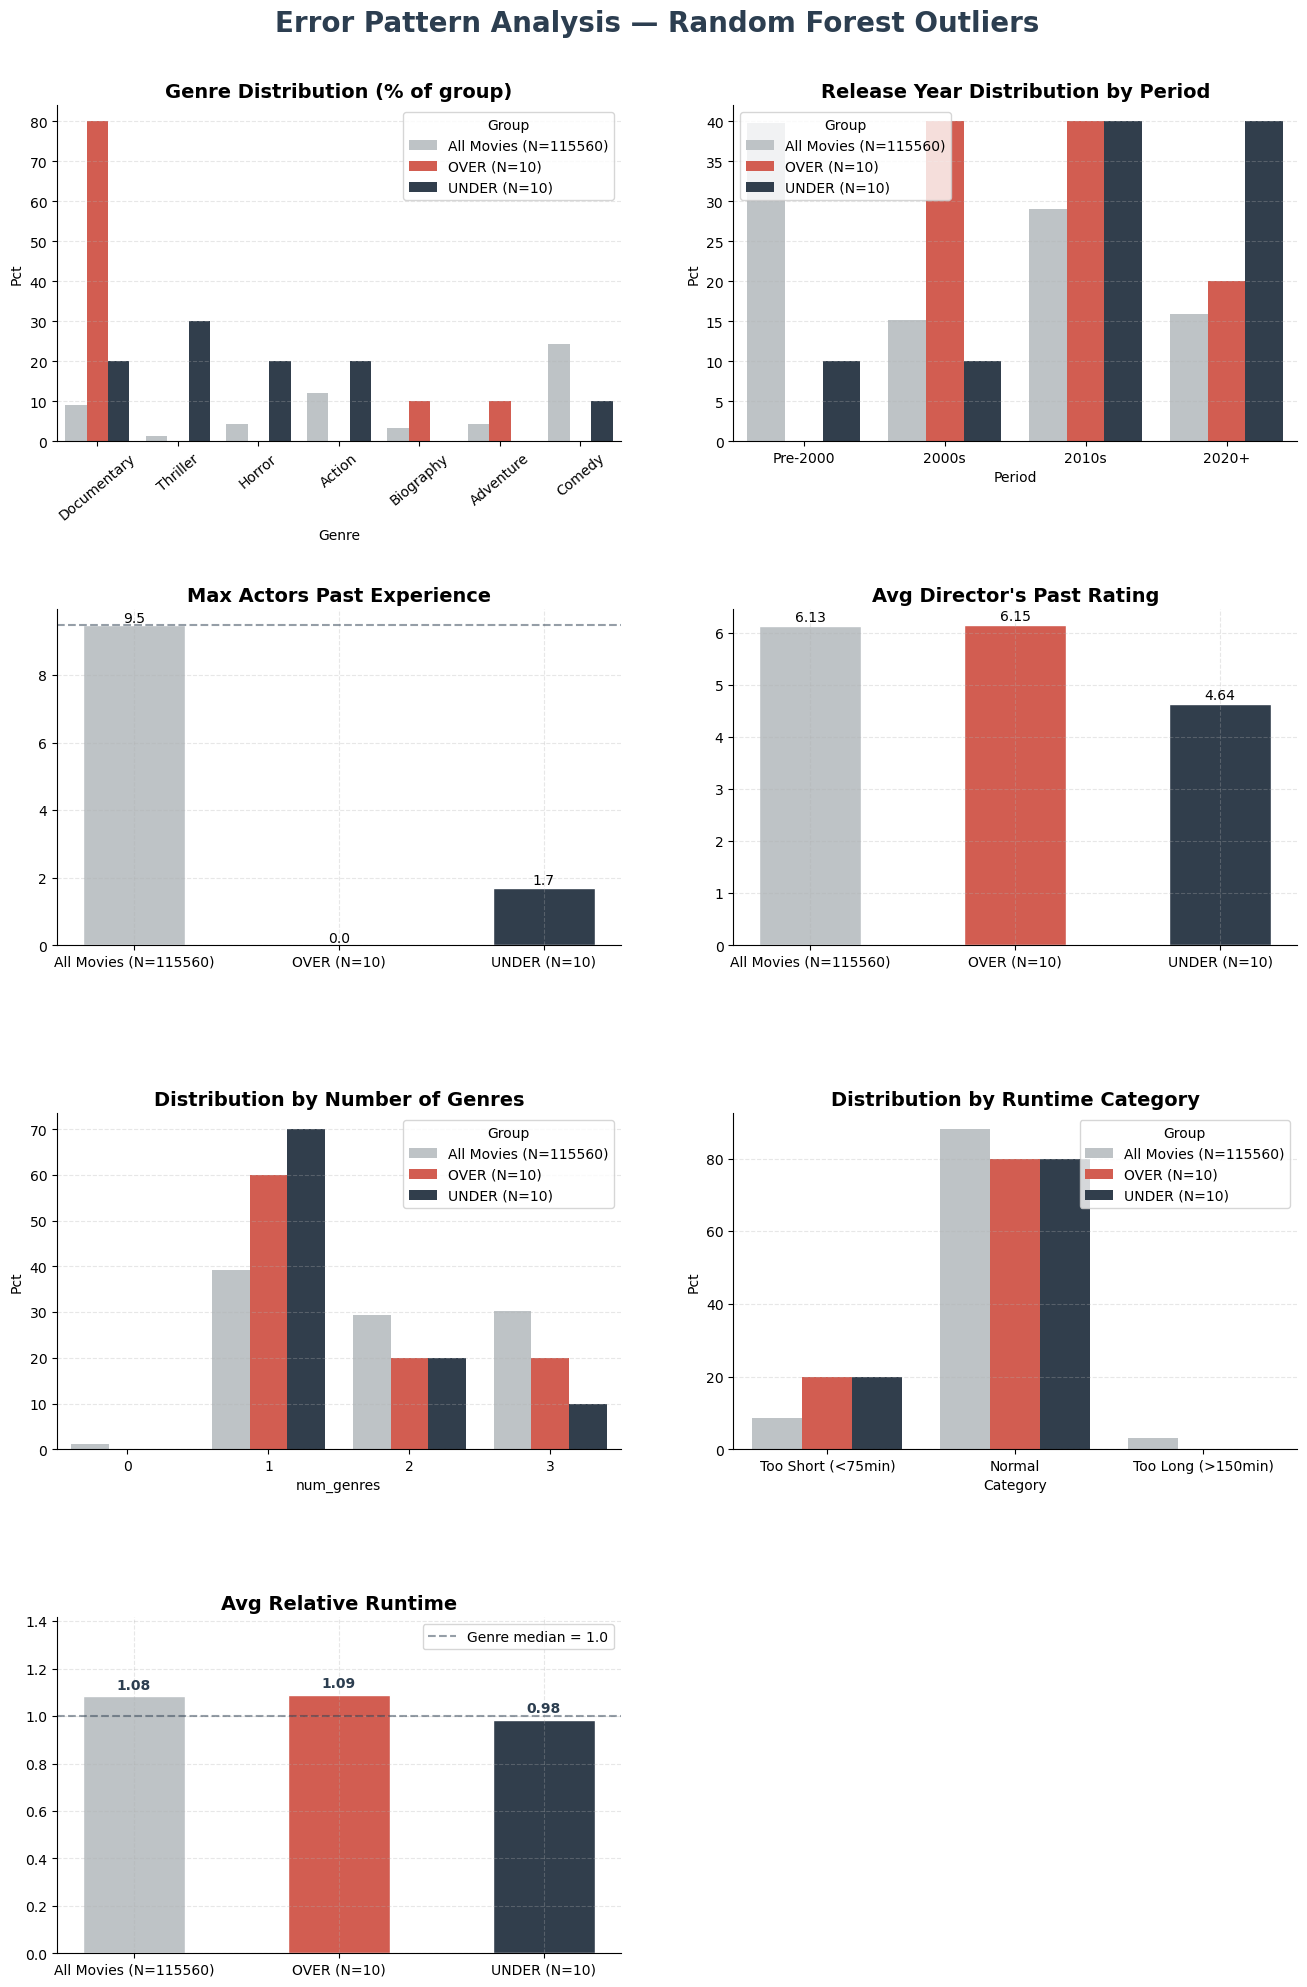

In [13]:
plt.rcParams.update({'font.family': 'sans-serif', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'grid.linestyle': '--'})

# פונקציה לחישוב ממוצע 
def safe_mean(series):
    s = pd.to_numeric(series, errors='coerce')
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    return s.mean() if len(s) > 0 else 0.0

n_all, n_over, n_under = len(errors_df), len(over_rf), len(under_rf)

group_order = [f'All Movies (N={n_all})', f'OVER (N={n_over})', f'UNDER (N={n_under})']
custom_colors = ['#bdc3c7', '#e74c3c', '#2c3e50']
pal = {
    group_order[0]: custom_colors[0],
    group_order[1]: custom_colors[1],
    group_order[2]: custom_colors[2]}
muted_colors = [sns.desaturate(c, 0.75) for c in custom_colors]

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.patch.set_facecolor('#ffffff')
fig.suptitle('Error Pattern Analysis — Random Forest Outliers',
             fontsize=20, fontweight='bold', color='#2c3e50', y=0.92)

# --- [0,0] Genre Distribution ---
top_genres = outliers_rf['first_genre'].value_counts().head(8).index.tolist()
rows = []
for genre in top_genres:
    rows += [
        {'Genre': genre, 'Group': group_order[0], 'Pct': (errors_df['first_genre'] == genre).mean() * 100},
        {'Genre': genre, 'Group': group_order[1], 'Pct': (over_rf['first_genre'] == genre).mean() * 100},
        {'Genre': genre, 'Group': group_order[2], 'Pct': (under_rf['first_genre'] == genre).mean() * 100}, ]

sns.barplot(data=pd.DataFrame(rows), x='Genre', y='Pct', hue='Group', hue_order=group_order, palette=pal, ax=axes[0, 0])
axes[0, 0].set_title('Genre Distribution (% of group)', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=40)

# --- [0,1] Release Year by Period ---
def year_to_period(year):
    if pd.isna(year): return 'Unknown'
    return 'Pre-2000' if year < 2000 else ('2000s' if year < 2010 else ('2010s' if year < 2020 else '2020+'))

periods = ['Pre-2000', '2000s', '2010s', '2020+']
rows = []
for p in periods:
    rows += [
        {'Period': p, 'Group': group_order[0], 'Pct': (errors_df['startYear'].apply(year_to_period) == p).mean() * 100},
        {'Period': p, 'Group': group_order[1], 'Pct': (over_rf['startYear'].apply(year_to_period) == p).mean() * 100},
        {'Period': p, 'Group': group_order[2], 'Pct': (under_rf['startYear'].apply(year_to_period) == p).mean() * 100},
    ]
sns.barplot(data=pd.DataFrame(rows), x='Period', y='Pct', hue='Group', hue_order=group_order, palette=pal, ax=axes[0, 1])
axes[0, 1].set_title('Release Year Distribution by Period', fontsize=14, fontweight='bold')

# --- [1,0] MAX Actors Past Experience ---
act_vals = [safe_mean(errors_df['max_actors_past_exp']), safe_mean(over_rf['max_actors_past_exp']), safe_mean(under_rf['max_actors_past_exp'])]
bars = axes[1, 0].bar(group_order, act_vals, color=muted_colors, edgecolor='white', width=0.5)
axes[1, 0].axhline(act_vals[0], color='#2c3e50', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Max Actors Past Experience', fontsize=14, fontweight='bold')
for bar, v in zip(bars, act_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.1f}', ha='center')

# --- [1,1] Director Past Avg ---
avg_vals = [safe_mean(errors_df['director_past_avg']), safe_mean(over_rf['director_past_avg']), safe_mean(under_rf['director_past_avg'])]
bars = axes[1, 1].bar(group_order, avg_vals, color=muted_colors, edgecolor='white', width=0.5)
axes[1, 1].set_title("Avg Director's Past Rating", fontsize=14, fontweight='bold')
for bar, v in zip(bars, avg_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}', ha='center')

# פונקציית עזר לגרפים של שורה 3
def make_pct_df(categories, all_ser, over_ser, under_ser, col='Category'):
    rows = []
    for cat in categories:
        rows += [
            {col: cat, 'Group': group_order[0], 'Pct': (all_ser == cat).mean() * 100},
            {col: cat, 'Group': group_order[1], 'Pct': (over_ser == cat).mean() * 100},
            {col: cat, 'Group': group_order[2], 'Pct': (under_ser == cat).mean() * 100},
        ]
    return pd.DataFrame(rows)

# --- [2,0] num_genres ---
ng_cats = sorted(errors_df['num_genres'].dropna().unique())
sns.barplot(data=make_pct_df(ng_cats, errors_df['num_genres'], over_rf['num_genres'], under_rf['num_genres'], col='num_genres'),
            x='num_genres', y='Pct', hue='Group', hue_order=group_order, palette=pal, ax=axes[2,0])
axes[2,0].set_title('Distribution by Number of Genres', fontsize=14, fontweight='bold')

# --- [2,1] runtime_category ---
all_rt_cat  = errors_df['runtime_category']
rt_cats = ['Too Short (<75min)', 'Normal', 'Too Long (>150min)']
sns.barplot(data=make_pct_df(rt_cats, all_rt_cat, over_rf['runtime_category'], under_rf['runtime_category']),
            x='Category', y='Pct', hue='Group', hue_order=group_order, palette=pal, ax=axes[2,1])
axes[2,1].set_title('Distribution by Runtime Category', fontsize=14, fontweight='bold')

# --- [3,0] relative runtime ---
rrt_vals = [
    safe_mean(errors_df['relative_runtime_by_genre']),
    safe_mean(over_rf['relative_runtime_by_genre']),
    safe_mean(under_rf['relative_runtime_by_genre'])]

bars = axes[3,0].bar(group_order, rrt_vals, color=muted_colors, edgecolor='white', width=0.5)
axes[3,0].axhline(1.0, color='#2c3e50', linestyle='--', alpha=0.5, label='Genre median = 1.0')
axes[3,0].set_title('Avg Relative Runtime', fontsize=14, fontweight='bold')
axes[3,0].legend()

max_val = max([v for v in rrt_vals if pd.notna(v)] + [1.0])
axes[3,0].set_ylim(0, max_val * 1.3)

for bar, v in zip(bars, rrt_vals):
    if pd.notna(v) and v > 0:
        axes[3,0].text(bar.get_x() + bar.get_width()/2, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold', color='#2c3e50')

# --- [3,1] Empty ---
axes[3, 1].axis('off')
plt.subplots_adjust(top=0.88, hspace=0.5, wspace=0.2)
plt.show()

## השוואת שגיאות בין מודלים

In [14]:
# השוואה בין המודלים
overlap_idx = outliers_rf.index.intersection(outliers_en.index)
only_rf     = outliers_rf.index.difference(outliers_en.index)
only_en     = outliers_en.index.difference(outliers_rf.index)

display(HTML(f"""
    <div style="margin:16px 0; padding:14px 20px; border-left:5px solid #2c3e50;
                background:#f8f9fa; font-family:sans-serif; border-radius:4px;">
        <div style="font-size:15px; font-weight:bold; color:#2c3e50; margin-bottom:8px;">
        Comparing outliers between models
</div>
        <table style="border-collapse:collapse; font-size:13px;">
            <tr>
                <td style="padding:3px 20px 3px 0; color:#555;">Joint films (both models)</td>
                <td style="font-weight:bold; color:#2c3e50;">{len(overlap_idx)} / 20</td>
            </tr>
            <tr>
                <td style="padding:3px 20px 3px 0; color:#555;">Unique to Random Forest</td>
                <td style="font-weight:bold; color:#2c3e50;">{len(only_rf)}</td>
            </tr>
            <tr>
                <td style="padding:3px 20px 3px 0; color:#555;">Unique to Elastic Net</td>
                <td style="font-weight:bold; color:#2c3e50;">{len(only_en)}</td>
            </tr>
        </table>
    </div>
"""))

if len(overlap_idx) > 0:
    COLS_OVERLAP = ['primaryTitle', 'y_true', 'pred_rf', 'pred_en', 'error_rf', 'error_en']
    show_titled_table(
        errors_df.loc[overlap_idx],
        "Movies that appear as outliers in both models",
        COLS_OVERLAP,
        highlight_col='error_rf',
        higher_is_better=False
    )

Joint films (both models),9 / 20
Unique to Random Forest,11
Unique to Elastic Net,11


,primaryTitle,y_true,pred_rf,pred_en,error_rf,error_en
1,Justin Bieber: Always Believing,1.00,7.24,6.85,6.24,5.85
2,Rape of the Soul,1.70,7.70,7.40,6.00,5.70
3,Kurz,1.20,7.06,7.14,5.86,5.94
4,Obama in NC: The Path to History,1.50,7.33,7.16,5.83,5.66
5,Ramo Trip,1.40,7.19,7.22,5.79,5.82
6,Tribalism Is Killing Us,1.30,6.97,6.87,5.67,5.57
7,Long Shot Louie,8.10,3.53,3.25,-4.57,-4.85
8,Another Year Together,8.90,4.50,4.32,-4.40,-4.58
9,Barumbado,8.80,4.42,4.11,-4.38,-4.69


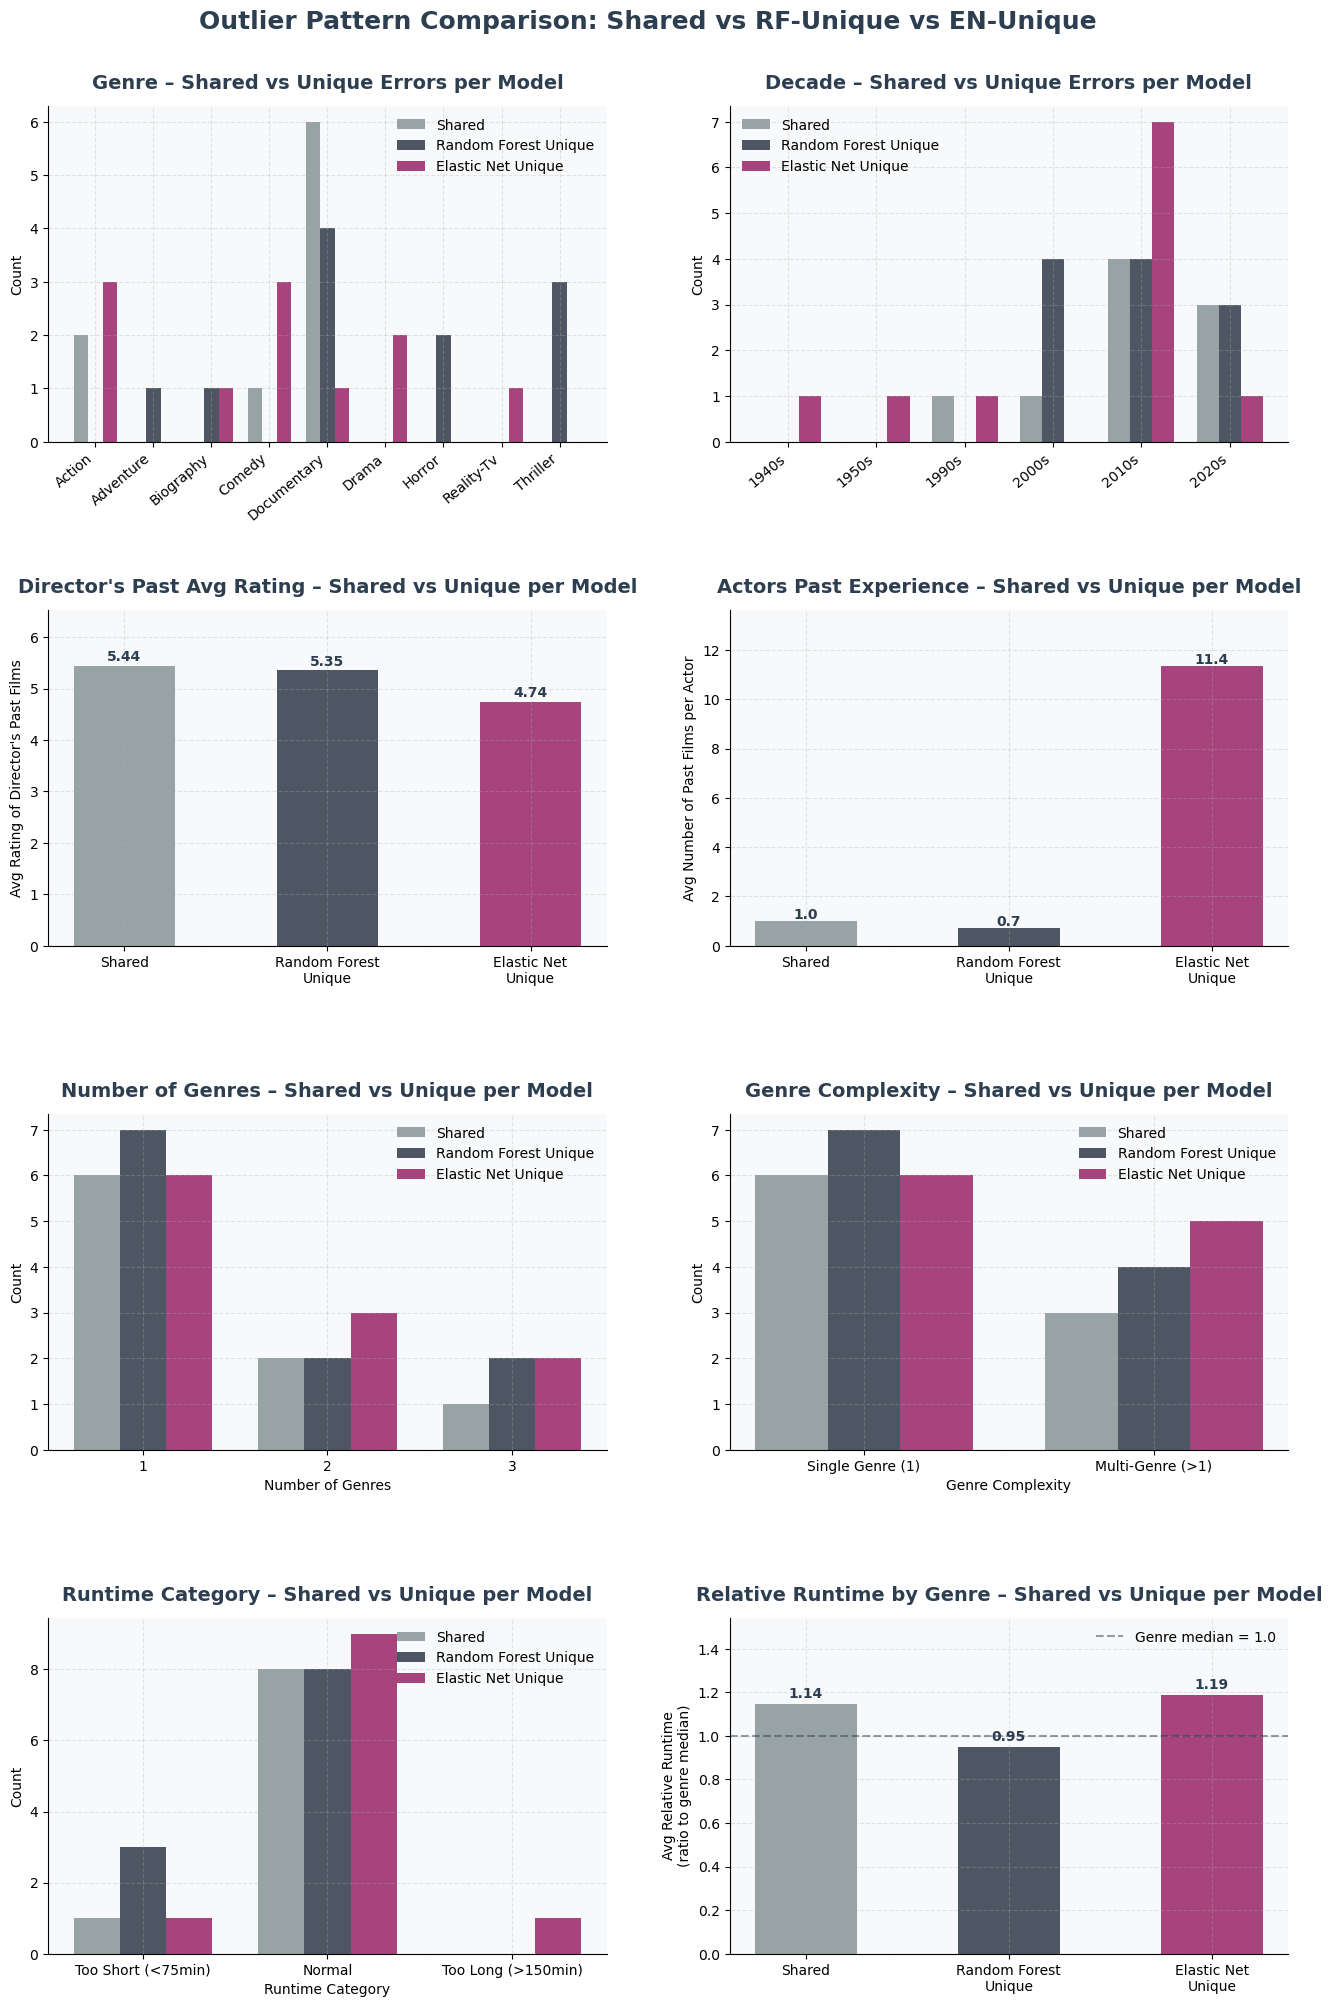

In [15]:
plt.rcParams.update({'font.family': 'sans-serif', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'grid.linestyle': '--'})

best_name  = "Random Forest"
other_name = "Elastic Net"

only_best  = outliers_rf.index.difference(outliers_en.index)
only_other = outliers_en.index.difference(outliers_rf.index)

sub_best   = errors_df.loc[only_best]
sub_other  = errors_df.loc[only_other]
sub_shared = errors_df.loc[overlap_idx]

groups = ['Shared', f'{best_name}\nUnique', f'{other_name}\nUnique']
w = 0.25
base_colors = ['#95a5a6', '#4A5568', '#B83280']
muted_colors = [sns.desaturate(c, 0.75) for c in base_colors]

c_shared = muted_colors[0] 
c_best   = muted_colors[1] 
c_other  = muted_colors[2] 

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.patch.set_facecolor('#ffffff')
fig.suptitle('Outlier Pattern Comparison: Shared vs RF-Unique vs EN-Unique',
             fontsize=18, fontweight='bold', color='#2c3e50', y=0.92)

def _style(ax, title):
    ax.set_title(title, fontsize=14, fontweight='bold', color='#2c3e50', pad=12)
    ax.set_facecolor('#f8f9fa')
    ax.spines[['top', 'right']].set_visible(False)

# [0,0] – ז'אנר
genre_shared = sub_shared['first_genre'].value_counts().head(6)
genre_best   = sub_best['first_genre'].value_counts().head(6)
genre_other  = sub_other['first_genre'].value_counts().head(6)
all_genres   = sorted(set(genre_shared.index) | set(genre_best.index) | set(genre_other.index))
x = range(len(all_genres))
axes[0, 0].bar([i - w for i in x], [genre_shared.get(g, 0) for g in all_genres], w, label='Shared', color=c_shared)
axes[0, 0].bar([i     for i in x], [genre_best.get(g, 0)   for g in all_genres], w, label=f'{best_name} Unique', color=c_best)
axes[0, 0].bar([i + w for i in x], [genre_other.get(g, 0)  for g in all_genres], w, label=f'{other_name} Unique', color=c_other)
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(all_genres, rotation=40, ha='right')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(frameon=False)
_style(axes[0, 0], 'Genre – Shared vs Unique Errors per Model')

# [0,1] – עשור
dec_shared = (sub_shared['startYear'] // 10 * 10).value_counts().sort_index()
dec_best   = (sub_best['startYear']   // 10 * 10).value_counts().sort_index()
dec_other  = (sub_other['startYear']  // 10 * 10).value_counts().sort_index()
all_dec    = sorted(set(dec_shared.index) | set(dec_best.index) | set(dec_other.index))
dec_labels = [f"{int(d)}s" for d in all_dec]
x = range(len(all_dec))
axes[0, 1].bar([i - w for i in x], [dec_shared.get(d, 0) for d in all_dec], w, label='Shared', color=c_shared)
axes[0, 1].bar([i     for i in x], [dec_best.get(d, 0)   for d in all_dec], w, label=f'{best_name} Unique', color=c_best)
axes[0, 1].bar([i + w for i in x], [dec_other.get(d, 0)  for d in all_dec], w, label=f'{other_name} Unique', color=c_other)
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(dec_labels, rotation=40, ha='right')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(frameon=False)
_style(axes[0, 1], 'Decade – Shared vs Unique Errors per Model')

# [1,0] – ממוצע דירוגי עבר של במאי
dir_v = [safe_mean(sub_shared['director_past_avg']),
         safe_mean(sub_best['director_past_avg']),
         safe_mean(sub_other['director_past_avg'])]
bars = axes[1, 0].bar(groups, dir_v, color=muted_colors, width=0.5)
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
axes[1, 0].set_ylim(0, max(dir_v) * 1.2 if max(dir_v) > 0 else 10)
for bar, v in zip(bars, dir_v):
    if v > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', color='#2c3e50')
_style(axes[1, 0], "Director's Past Avg Rating – Shared vs Unique per Model")

# [1,1] – ניסיון מקסימלי של אחד השחקנים הראשיים
act_v = [safe_mean(sub_shared['max_actors_past_exp']),
         safe_mean(sub_best['max_actors_past_exp']),
         safe_mean(sub_other['max_actors_past_exp'])]
bars = axes[1, 1].bar(groups, act_v, color=muted_colors, width=0.5)
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
axes[1, 1].set_ylim(0, max(act_v) * 1.2 if max(act_v) > 0 else 10)
for bar, v in zip(bars, act_v):
    if v > 0:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold', color='#2c3e50')
_style(axes[1, 1], 'Actors Past Experience – Shared vs Unique per Model')

# [2,0] – מספר ז'אנרים
num_genres_shared = sub_shared['num_genres'].value_counts().sort_index()
num_genres_best   = sub_best['num_genres'].value_counts().sort_index()
num_genres_other  = sub_other['num_genres'].value_counts().sort_index()
all_nums          = sorted(set(num_genres_shared.index) | set(num_genres_best.index) | set(num_genres_other.index))
x_nums            = range(len(all_nums))
axes[2, 0].bar([i - w for i in x_nums], [num_genres_shared.get(n, 0) for n in all_nums], w, label='Shared', color=c_shared)
axes[2, 0].bar([i     for i in x_nums], [num_genres_best.get(n, 0)   for n in all_nums], w, label=f'{best_name} Unique', color=c_best)
axes[2, 0].bar([i + w for i in x_nums], [num_genres_other.get(n, 0)  for n in all_nums], w, label=f'{other_name} Unique', color=c_other)
axes[2, 0].set_xticks(list(x_nums))
axes[2, 0].set_xticklabels([str(n) for n in all_nums])
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_xlabel('Number of Genres')
axes[2, 0].legend(frameon=False)
_style(axes[2, 0], 'Number of Genres – Shared vs Unique per Model')

# [2,1] – מורכבות ז'אנר
comp_shared = sub_shared['num_genres'].apply(lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_best   = sub_best['num_genres'].apply(  lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_other  = sub_other['num_genres'].apply( lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
all_comps   = ['Single Genre (1)', 'Multi-Genre (>1)']
x_comps     = range(len(all_comps))
axes[2, 1].bar([i - w for i in x_comps], [comp_shared.get(c, 0) for c in all_comps], w, label='Shared', color=c_shared)
axes[2, 1].bar([i     for i in x_comps], [comp_best.get(c, 0)   for c in all_comps], w, label=f'{best_name} Unique', color=c_best)
axes[2, 1].bar([i + w for i in x_comps], [comp_other.get(c, 0)  for c in all_comps], w, label=f'{other_name} Unique', color=c_other)
axes[2, 1].set_xticks(list(x_comps))
axes[2, 1].set_xticklabels(all_comps)
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_xlabel('Genre Complexity')
axes[2, 1].legend(frameon=False)
_style(axes[2, 1], 'Genre Complexity – Shared vs Unique per Model')

# [3,0] – קטגוריות זמן ריצה
def _runtime_counts(sub_df):
    return sub_df['runtime_category'].value_counts()

rt_cats = ['Too Short (<75min)', 'Normal', 'Too Long (>150min)']
rt_shared = _runtime_counts(sub_shared)
rt_best   = _runtime_counts(sub_best)
rt_other  = _runtime_counts(sub_other)
x_rt      = range(len(rt_cats))
axes[3, 0].bar([i - w for i in x_rt], [rt_shared.get(c, 0) for c in rt_cats], w, label='Shared', color=c_shared)
axes[3, 0].bar([i     for i in x_rt], [rt_best.get(c, 0)   for c in rt_cats], w, label=f'{best_name} Unique', color=c_best)
axes[3, 0].bar([i + w for i in x_rt], [rt_other.get(c, 0)  for c in rt_cats], w, label=f'{other_name} Unique', color=c_other)
axes[3, 0].set_xticks(list(x_rt))
axes[3, 0].set_xticklabels(rt_cats)
axes[3, 0].set_ylabel('Count')
axes[3, 0].set_xlabel('Runtime Category')
axes[3, 0].legend(frameon=False)
_style(axes[3, 0], 'Runtime Category – Shared vs Unique per Model')

# [3,1] – זמן ריצה ביחס לחציון הזאנר
rrt_v = [safe_mean(sub_shared['relative_runtime_by_genre']),
         safe_mean(sub_best['relative_runtime_by_genre']),
         safe_mean(sub_other['relative_runtime_by_genre'])]
bars = axes[3, 1].bar(groups, rrt_v, color=muted_colors, width=0.5)
axes[3, 1].set_ylabel('Avg Relative Runtime\n(ratio to genre median)')
axes[3, 1].axhline(1.0, color='#2c3e50', linestyle='--', alpha=0.5, label='Genre median = 1.0')
axes[3, 1].set_ylim(0, max(rrt_v + [1.0]) * 1.3)
axes[3, 1].legend(frameon=False)
for bar, v in zip(bars, rrt_v):
    if v > 0:
        axes[3, 1].text(bar.get_x() + bar.get_width()/2, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold', color='#2c3e50')
_style(axes[3, 1], 'Relative Runtime by Genre – Shared vs Unique per Model')

plt.subplots_adjust(top=0.88, hspace=0.5, wspace=0.22)
plt.show()

## ניתוח הוגנות

In [16]:
fairness_df = errors_df.copy()
fairness_df['decade'] = (fairness_df['startYear'] // 10 * 10).astype('Int64')
overall_rmse = np.sqrt(mean_squared_error(fairness_df['y_true'], fairness_df['pred_rf']))
overall_mae  = mean_absolute_error(fairness_df['y_true'], fairness_df['pred_rf'])
def slice_metrics(df, label):
    rmse = np.sqrt(mean_squared_error(df['y_true'], df['pred_rf']))
    mae  = mean_absolute_error(df['y_true'], df['pred_rf'])
    
    # חישוב פערי האחוזים משני המדדים
    pct_rmse = (rmse / overall_rmse - 1) * 100
    pct_mae  = (mae / overall_mae - 1) * 100
    
    return {
        'Slice': label, 
        'N': len(df),
        'RMSE': round(rmse, 4), 
        'MAE': round(mae, 4),
        'RMSE vs overall': f'{pct_rmse:+.1f}%',
        'MAE vs overall': f'{pct_mae:+.1f}%' }

In [17]:
# By Genre (top 5, multi-label)
genre_rows = []
for _, row in fairness_df.iterrows():
    for g in (row['genres'] if isinstance(row['genres'], list) else []):
        genre_rows.append(row.to_dict() | {'genre_label': g})
genre_long  = pd.DataFrame(genre_rows)
top5_genres = genre_long['genre_label'].value_counts().head(5).index
genre_df = pd.DataFrame([
    slice_metrics(genre_long[genre_long['genre_label'] == g], g)
    for g in top5_genres])

,Slice,N,RMSE,MAE,RMSE vs overall,MAE vs overall
0,Drama,58460,1.026600,0.782200,-5.4%,-5.1%
1,Comedy,33316,1.091800,0.832600,+0.6%,+1.0%
2,Romance,15693,0.986200,0.750100,-9.1%,-9.0%
3,Action,13987,1.159600,0.890800,+6.9%,+8.1%
4,Documentary,13014,1.026800,0.765500,-5.4%,-7.1%


,Slice,N,RMSE,MAE,RMSE vs overall,MAE vs overall
0,1930s,3121,0.799500,0.595600,-26.3%,-27.7%
1,1940s,3292,0.768400,0.575700,-29.2%,-30.1%
2,1950s,4602,0.848000,0.644400,-21.8%,-21.8%
3,1960s,6208,0.929700,0.720900,-14.3%,-12.5%
4,1970s,7969,0.951600,0.738900,-12.3%,-10.3%
5,1980s,9631,0.992400,0.768200,-8.5%,-6.8%
6,1990s,10213,1.028600,0.796000,-5.2%,-3.4%
7,2000s,17555,1.127800,0.861700,+3.9%,+4.6%
8,2010s,33605,1.162800,0.884400,+7.2%,+7.3%
9,2020s,18405,1.216300,0.927300,+12.1%,+12.5%


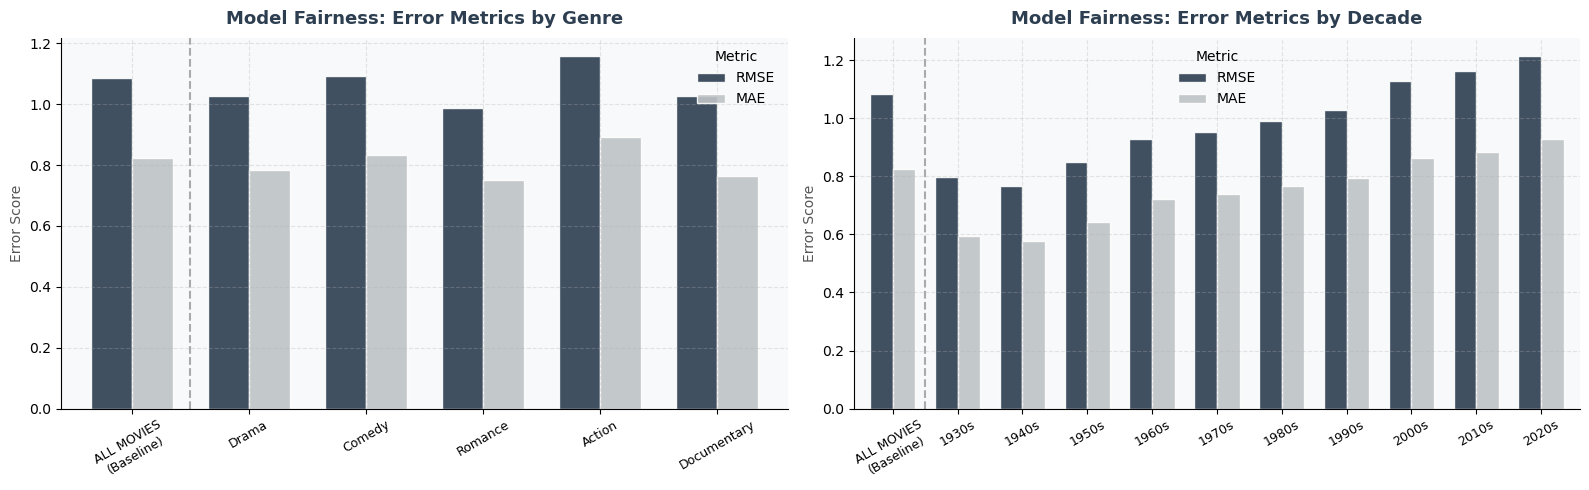

In [18]:
available_decades = sorted(fairness_df['decade'].dropna().unique())
last_10_decades = available_decades[-10:]
decade_df = pd.DataFrame([
    slice_metrics(fairness_df[fairness_df['decade'] == dec], f"{int(dec)}s")
    for dec in last_10_decades
    if len(fairness_df[fairness_df['decade'] == dec]) > 0
])

# עיצוב טבלת הזאנרים
display(HTML("""
    <div style="margin: 16px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Error by Genre (Top 5)
        </span>
    </div>
"""))
display(style_table(genre_df.reset_index(drop=True), highlight_col='RMSE', higher_is_better=False))

# עיצוב טבלת העשורים
display(HTML("""
    <div style="margin: 24px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Error by Decade (Full Decades)
        </span>
    </div>
"""))
display(style_table(decade_df.reset_index(drop=True), highlight_col='RMSE', higher_is_better=False))

overall_row = pd.DataFrame([{
    'Slice': 'ALL MOVIES\n(Baseline)',
    'RMSE': overall_rmse,
    'MAE': overall_mae}])

plot_genre_df  = pd.concat([overall_row, genre_df],  ignore_index=True)
plot_decade_df = pd.concat([overall_row, decade_df], ignore_index=True)

RMSE_CLR = '#2c3e50'
MAE_CLR  = sns.desaturate('#bdc3c7', 0.75) 

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#ffffff')

# גרף שמאל - ז'אנרים
plot_genre_df.set_index('Slice')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[0], color=[RMSE_CLR, MAE_CLR],
    width=0.7, edgecolor='white', alpha=0.9)
axes[0].set_ylabel('Error Score', color='#555')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].legend(title='Metric', frameon=False)
axes[0].axvline(0.5, color='#aaa', linestyle='--', linewidth=1.5)
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title('Model Fairness: Error Metrics by Genre',
                  fontsize=13, fontweight='bold', color='#2c3e50', pad=10)

# גרף ימין - עשורים מלאים 
plot_decade_df.set_index('Slice')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[1], color=[RMSE_CLR, MAE_CLR],
    width=0.7, edgecolor='white', alpha=0.9)
axes[1].set_ylabel('Error Score', color='#555')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1].legend(title='Metric', frameon=False)
axes[1].axvline(0.5, color='#aaa', linestyle='--', linewidth=1.5)
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_title('Model Fairness: Error Metrics by Decade',
                  fontsize=13, fontweight='bold', color='#2c3e50', pad=10)

plt.tight_layout()
plt.show()

## ניתוח חשיבות הפיצרים 

,Feature,EN_coef
0,director_genre_past_avg,0.419500
1,relative_runtime_by_genre,0.253900
2,director_past_avg,0.166200
3,is_new_actors,0.124700
4,is_too_short,0.072700


,Feature,RF_importance
0,director_genre_past_avg,0.572900
1,director_past_avg,0.147600
2,relative_runtime_by_genre,0.142600
3,startYear,0.047500
4,max_actors_past_experience,0.041200


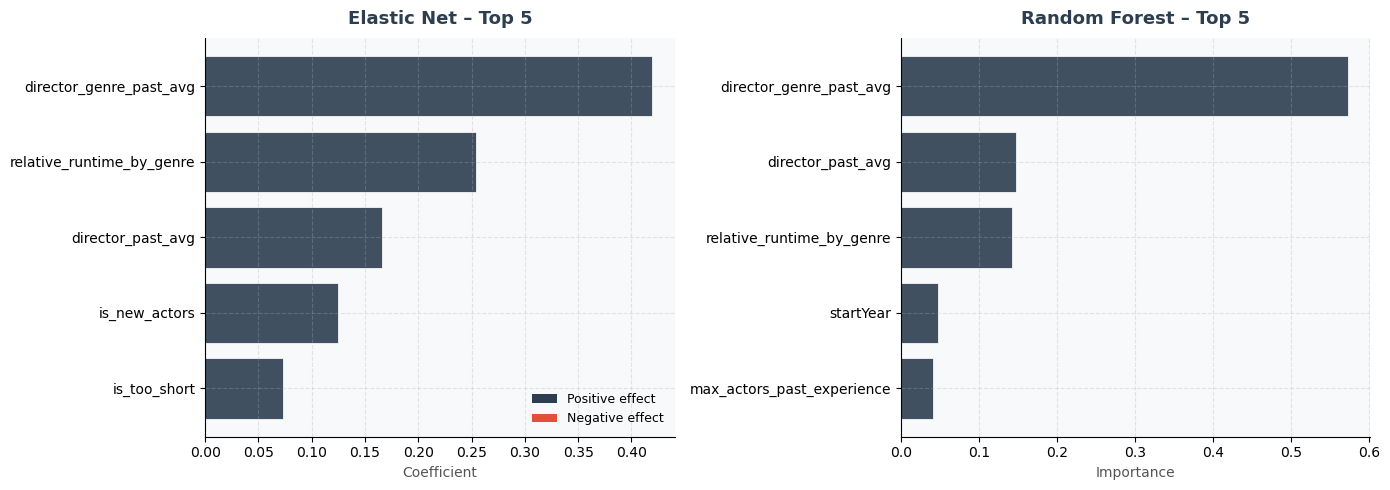

In [20]:
en_coefs = pipeline_en['model'].best_estimator_.coef_
rf_importances = pipeline_rf['model'].best_estimator_.feature_importances_

feat_df = pd.DataFrame({
    'Feature':FEATURE_COLS,
    'EN_coef':en_coefs,
    'RF_importance': rf_importances,})
# top-5 לפי כל מודל בנפרד
top5_en = feat_df.reindex(feat_df['EN_coef'].abs().sort_values(ascending=False).index).head(5)
top5_rf = feat_df.sort_values('RF_importance', ascending=False).head(5)

# עיצוב טבלאות
display(HTML("""
    <div style="margin: 16px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Elastic Net – Top 5 Features
        </span>
    </div>
"""))
display(style_table(top5_en[['Feature', 'EN_coef']].round(4).reset_index(drop=True)))

display(HTML("""
    <div style="margin: 24px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Random Forest – Top 5 Features
        </span>
    </div>
"""))
display(style_table(top5_rf[['Feature', 'RF_importance']].round(4).reset_index(drop=True)))

# גרפים
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# Elastic Net — חיובי/שלילי בצבעים שונים
en_sorted  = top5_en.set_index('Feature')['EN_coef'].sort_values()
colors_en  = ['#e74c3c' if c < 0 else '#2c3e50' for c in en_sorted]
axes[0].barh(range(len(en_sorted)), en_sorted.values,
             color=colors_en, edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0].set_yticks(range(len(en_sorted)))
axes[0].set_yticklabels(en_sorted.index, fontsize=10)
axes[0].axvline(0, color='#2c3e50', linewidth=1.2)
axes[0].set_xlabel('Coefficient', color='#555')
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title('Elastic Net – Top 5', fontsize=13,
                  fontweight='bold', color='#2c3e50', pad=10)

axes[0].legend(handles=[Patch(fc='#2c3e50', label='Positive effect'),
                         Patch(fc='#e74c3c', label='Negative effect')],
               frameon=False, fontsize=9)

# Random Forest — importance 
rf_sorted = top5_rf.set_index('Feature')['RF_importance'].sort_values()
axes[1].barh(range(len(rf_sorted)), rf_sorted.values,
             color='#2c3e50', edgecolor='white', linewidth=0.6, alpha=0.9)
axes[1].set_yticks(range(len(rf_sorted)))
axes[1].set_yticklabels(rf_sorted.index, fontsize=10)
axes[1].set_xlabel('Importance', color='#555')
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_title('Random Forest – Top 5', fontsize=13,fontweight='bold', color='#2c3e50', pad=10)

plt.tight_layout()
plt.show()

## שמירת המודל הטוב 


In [21]:
#  אימון סופי על כל הדאטה השלם שלך (X ו-y) כדי להגיע לדירוג הכי גבוה בתחרות
pipeline_rf.fit(X, y)

# שמירת ה-Pipeline המלא לקובץ pkl
joblib.dump(pipeline_rf, 'model.pkl')
print(" ה-Pipeline המוביל אומן על כל הנתונים ונשמר בהצלחה כ-model.pkl!")

# בדיקת שפיות - טעינה מחדש של המודל מהקובץ
loaded_model = joblib.load('model.pkl')
#הרצת דמו 
demo_predictions = loaded_model.predict(X.head(3))

print("\n--- בדיקת שפיות למודל השמור ---")
print("התחזיות (הדירוגים החזויים) עבור 3 הסרטים הראשונים בדאטה:")
print(demo_predictions)

 ה-Pipeline המוביל אומן על כל הנתונים ונשמר בהצלחה כ-model.pkl!

--- בדיקת שפיות למודל השמור ---
התחזיות (הדירוגים החזויים) עבור 3 הסרטים הראשונים בדאטה:
[5.61947926 6.15807575 5.75080011]
